### 1. 패키지 설치

In [1]:
%pip install -qU langchain langchain_openai tavily langgraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

### 2. 검색 API 도구
- https://app.tavily.com에서 KEY 발급 후 .env 파일에 'TAVILY_API_KEY=값' 입력

    - 사용법(기본): https://docs.tavily.com/agents
    - 옵션값 설정: https://docs.tavily.com/documentation/api-reference/endpoint/search

In [ ]:
from langchain_core.tools import tool
from tavily import TavilyClient

client = TavilyClient()

@tool
def search_web(query: str) -> list[dict]:
    """웹에서 최신 정보나 외부 자료를 검색합니다"""
    
    response = client.search(
        query=query,
        search_depth="basic",
        max_results=5,
        include_raw_content=False
    )

    return response.get("results", [])

In [ ]:
# 권장되는 방법
#search_response = search_web.invoke(
#    {"query": "오늘 서울 날씨 알려줘"}
#)

# 권장되지 않는 방법
#search_response = search_web.invoke("오늘 서울 날씨 알려줘")

### 3. State 정의
- `messages`에 `add_messages` reducer를 붙여 노드가 반환한 메시지를 덮어쓰지 않고 누적함

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]   # add_messages reducer로 메시지를 누적 (덮어쓰지 않음)

### 4. LLM에 도구 바인딩
- `bind_tools`로 도구 스키마를 LLM에 전달 → LLM이 필요하다고 판단하면 `tool_calls`를 생성함

In [ ]:
tools = [search_web]   # 그래프에서 사용할 도구 목록

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini"
)

llm_with_tools = llm.bind_tools(tools)   # 도구 스키마를 LLM에 바인딩 → 필요 시 tool_calls 생성

### 5. 노드(챗봇) 정의
- 누적된 `messages`를 `llm_with_tools`에 넘기고 응답을 리스트로 반환 → `add_messages`가 누적함

In [ ]:
def chatbot(state: State):   # 누적된 messages를 LLM에 전달, 응답을 리스트로 반환 → add_messages가 누적
    answer = llm_with_tools.invoke(
        state["messages"]
    )
    
    return {
        "messages": [answer]
    }

### 6. 그래프 구성 및 컴파일
- `ToolNode`: LLM이 만든 `tool_calls`를 실행하고 결과를 `ToolMessage`로 반환하는 prebuilt 노드
- `tools_condition`: 마지막 메시지에 `tool_calls`가 있으면 `tools`로, 없으면 `END`로 분기하는 prebuilt 조건 함수
- `chatbot → tools → chatbot` 루프로 도구 결과를 다시 LLM에 넘겨 최종 답변을 생성함
- 참고: https://reference.langchain.com/python/langgraph.prebuilt/tool_node/tools_condition

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot", chatbot
)

graph_builder.add_node(
    "tools",
    ToolNode(tools)   # tool_calls를 실행해 ToolMessage로 반환하는 prebuilt 노드
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition   # tool_calls가 있으면 "tools", 없으면 END로 분기
)

graph_builder.add_edge(
    "tools",
    "chatbot"   # 도구 결과를 다시 LLM에 전달 → 최종 답변 생성 (chatbot ⇄ tools 루프)
)

graph = graph_builder.compile()

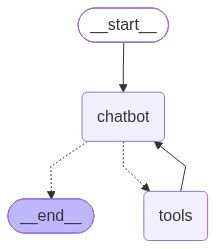

In [11]:
graph

### 7. 실행 (stream)
- `stream`은 노드 실행 단위로 이벤트를 방출 → `chatbot` / `tools` 단계별 state를 순차적으로 확인 가능
- 도구가 필요한 질문은 `chatbot → tools → chatbot`, 불필요한 질문은 `chatbot`에서 바로 종료됨

In [ ]:
# tool calling 테스트
question = "오늘 서울 날씨 알려줘"

for event in graph.stream(
    {
        "messages": [
            ("user", question)
        ]
    }
):
    for key, value in event.items():
        print(f"\n{'=' * 50}")
        print(f"STEP: {key}")
        print(f"{'=' * 50}")
        print(value["messages"][-1])


STEP: chatbot
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 55, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E3CZrWdWhVlWSZfwEPdSlAfnkNGWj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f7870-1129-7471-90e1-93bdf7545413-0' tool_calls=[{'name': 'search_web', 'args': {'query': '서울 날씨 오늘'}, 'id': 'call_511PJgooHKz6A2kIGjm6CKHB', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 55, 'output_tokens': 17, 'total_tokens': 72, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 're

In [ ]:
# 단순 LLM 답변 테스트
question = "LLM의 정의에 대해서 짧고 간결하게 말해줘"

for event in graph.stream(
    {
        "messages": [
            ("user", question)
        ]
    }
):
    for key, value in event.items():
        print(f"\n{'=' * 50}")
        print(f"STEP: {key}")
        print(f"{'=' * 50}")
        print(value["messages"][-1])


STEP: chatbot
content='LLM(대규모 언어 모델)은 대량의 텍스트 데이터를 학습하여 자연어 처리 작업을 수행하는 인공지능 모델입니다. 이러한 모델은 텍스트 생성, 요약, 번역, 질문 응답 등 다양한 언어 관련 작업에 사용됩니다. LLM은 일반적으로 심층 학습 기술을 기반으로 하며, 인간의 언어를 이해하고 생성하는 능력을 향상시킵니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 64, 'total_tokens': 159, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E3CbffcljZ1bZCvisBW6XKyGtkVUG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f7871-cab9-7bc1-9496-409ba6491ca5-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 64, 'output_tokens': 95, 'total_tokens': 159, 'input_token_details': {'audio': 0, '

### 8. 실행 (invoke)
- `invoke`는 그래프를 끝까지 실행한 뒤 최종 state를 한 번에 반환 (중간 단계는 노출하지 않음)
- `stream` 방식이 권장되나 동일 그래프를 `invoke`로도 실행 가능함

In [15]:
# Stream 방식이 아닌 invoke 방식(stream 방식이 권장되나 이렇게 사용도 가능하다는 부분을 보여주기 위해)

# tool calling 테스트
question = "오늘 서울 날씨 알려줘"

response = graph.invoke({"messages": [question]})

print(response)

{'messages': [HumanMessage(content='오늘 서울 날씨 알려줘', additional_kwargs={}, response_metadata={}, id='2bc5b077-6efa-4462-b06f-85ef6ec384b8'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 55, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E3CefjQtq8PyPhwzBVhVmwDOMcyjj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f7874-9f2e-7ee1-9a8e-ff938e067b16-0', tool_calls=[{'name': 'search_web', 'args': {'query': '서울 날씨'}, 'id': 'call_8sAGwwDtNBj0RPORZ48Wy6z2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 55